# Record Deletions:
- line 23 contained 5 spaces in the center of the "email" field, reading "vbe_____nchl@narod.ru"
- line 4929 had no data, consisting only of 10 commas
- line 7320 contained an additional column following the "ip" field, with text "agan", shifting all columns afterward to the right, and adding an additional column

# Import Modules

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt   #graphing utility
import math
import numpy as np

In [2]:
#open data file
df = pd.read_csv("data\\eStoreData.csv",header=0)

In [3]:
def apct(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d})"

In [4]:
def currency_fmt(x):
    if x >= 1_000_000:
        return f'${x/1_000_000:.4f}M'
    return f'${x/1_000:.4f}K'

# Department Spending

     department        cost
0    Automotive  2046860.05
1          Baby  2162215.55
2        Beauty  2016094.01
3         Books  2065691.14
4      Clothing  1942629.94
5     Computers  2245302.01
6   Electronics  1947221.64
7         Games  2137444.00
8        Garden  2090998.67
9       Grocery  2070654.29
10       Health  2218412.25
11         Home  2183144.84
12   Industrial  1841218.65
13     Jewelery  2199147.40
14         Kids  1771243.59
15       Movies  2011581.19
16        Music  2200114.25
17     Outdoors  1901006.87
18        Shoes  2111737.35
19       Sports  2216539.73
20        Tools  2099680.87
21         Toys  1895472.56
22          idk     4947.48


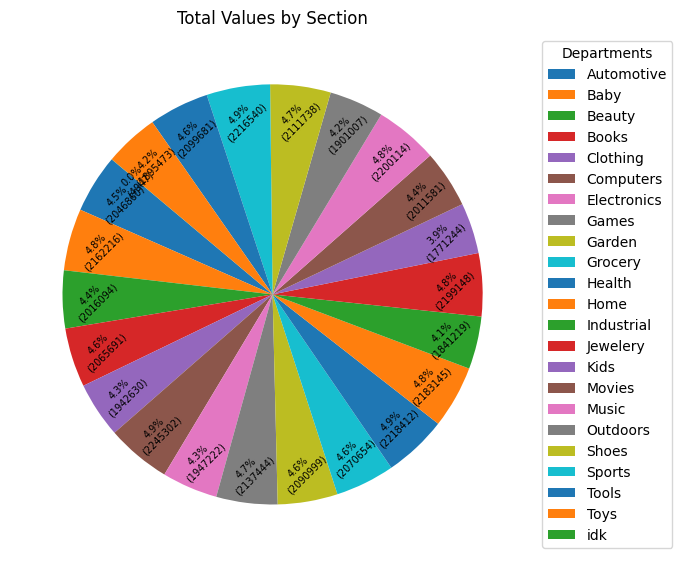

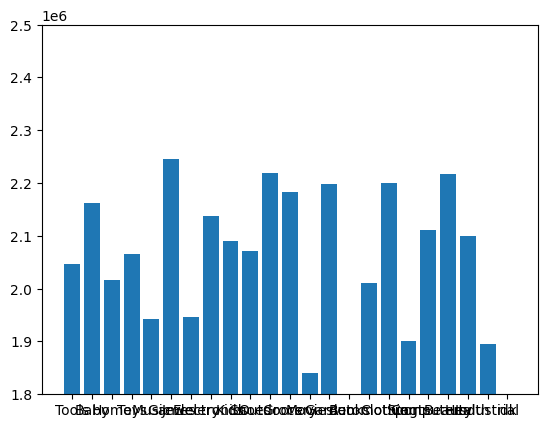

In [18]:
# Group by the 'Department' section and sum the 'Cost' sections
result = df.groupby('department')['cost'].sum().reset_index()
print(result)

# 1. Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot without labels on the wedges (labels=None)
# Use 'pctdistance' to push the percentages further out or in
wedges, texts, autotexts = ax.pie(
    result['cost'], 
    labels=None, 
    autopct=lambda pct: apct(pct, result['cost']),
    pctdistance=0.85, 
    startangle=140
)

# Shrink the percentage text and rotate it
# This prevents them from bumping into each other in small slices
for autotext in autotexts:
    autotext.set_fontsize(7)  # Smaller font
    autotext.set_rotation(45)

# 3. Add a legend to the side
# This keeps the department names clear and organized
ax.legend(
    wedges, 
    result['department'],
    title="Departments",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1) # Moves legend outside the plot area
)

ax.set_title('Total Values by Section')
plt.tight_layout()
plt.show()

# Top and Bottom Spending

   department        cost
5   Computers  2287323.26
13   Jewelery  2260148.15
10     Health  2252098.37
19     Sports  2243003.90
16      Music  2224369.86
    department        cost
17    Outdoors  1929507.68
21        Toys  1918046.00
12  Industrial  1858635.32
14        Kids  1815241.71
22         idk     4947.48


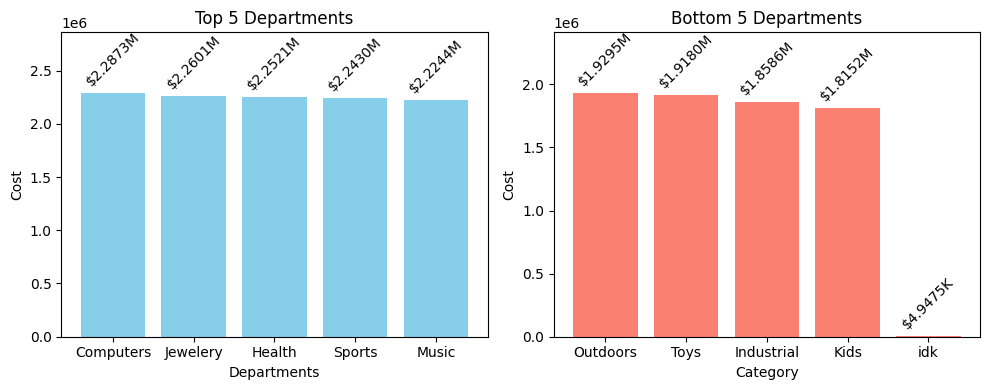

In [6]:
# 1. Sort the Departments by spending
sortedDeps = result.sort_values(by='cost', ascending=False)

# 2. Get the top 5 departments and the bottom 5 departments in terms of spending
top5_df = sortedDeps.head(5)
bottom5_df = sortedDeps.tail(5)
print(top5_df)
print(bottom5_df)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# 3. Plot the first DataFrame on the first axis (ax1)
TopBars = ax1.bar(top5_df['department'], top5_df['cost'], color='skyblue')
ax1.bar_label(TopBars, labels=[currency_fmt(x) for x in top5_df['cost']], padding=3, rotation=45)
ax1.set_title('Top 5 Departments')
ax1.set_xlabel('Departments')
ax1.set_ylabel('Cost')
ax1.set_ylim(0, top5_df['cost'].max() * 1.25) # Added padding for rotated text

# 4. Plot the second DataFrame on the second axis (ax2)
BottomBars = ax2.bar(bottom5_df['department'], bottom5_df['cost'], color='salmon')
ax2.bar_label(BottomBars, labels=[currency_fmt(x) for x in bottom5_df['cost']], padding=3, rotation=45)
ax2.set_title('Bottom 5 Departments')
ax2.set_xlabel('Category')
ax2.set_ylabel('Cost')
ax2.set_ylim(0, bottom5_df['cost'].max() * 1.25)

# 5. Adjust layout for better spacing and display the plot
plt.tight_layout() #
plt.show()

# Data Cleaning

In [7]:
invalid_prefixes = ('0.', '192.', '127.', '255.')
df = df[~df['ip'].str.startswith(invalid_prefixes)]
showClean = input("Would you like to show the Clean data? (y/n): ")
if showClean.lower() == "y":
    print(df)

Would you like to show the Clean data? (y/n):  n


# Rerun Department Spending and Top/Bottom Spending after cleaning

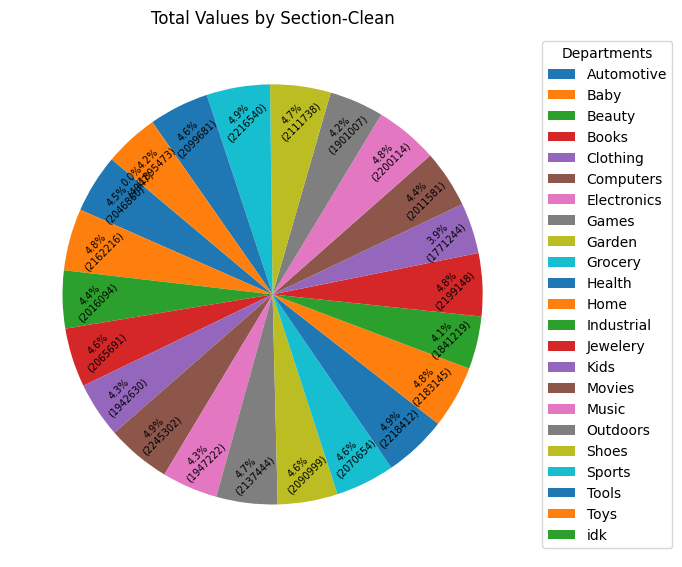

     department        cost
0    Automotive  2046860.05
1          Baby  2162215.55
2        Beauty  2016094.01
3         Books  2065691.14
4      Clothing  1942629.94
5     Computers  2245302.01
6   Electronics  1947221.64
7         Games  2137444.00
8        Garden  2090998.67
9       Grocery  2070654.29
10       Health  2218412.25
11         Home  2183144.84
12   Industrial  1841218.65
13     Jewelery  2199147.40
14         Kids  1771243.59
15       Movies  2011581.19
16        Music  2200114.25
17     Outdoors  1901006.87
18        Shoes  2111737.35
19       Sports  2216539.73
20        Tools  2099680.87
21         Toys  1895472.56
22          idk     4947.48


In [8]:
#################### Department Clean ####################
result = df.groupby('department')['cost'].sum().reset_index()
fig, ax = plt.subplots(figsize=(10, 6))

wedges, texts, autotexts = ax.pie(
    result['cost'], 
    labels=None, 
    autopct=lambda pct: apct(pct, result['cost']),
    pctdistance=0.85, 
    startangle=140
)

for autotext in autotexts:
    autotext.set_fontsize(7)  # Smaller font
    autotext.set_rotation(45)

ax.legend(
    wedges, 
    result['department'],
    title="Departments",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1) # Moves legend outside the plot area
)

ax.set_title('Total Values by Section-Clean')
plt.tight_layout()
plt.show()
print(result)

   department        cost
5   Computers  2245302.01
10     Health  2218412.25
19     Sports  2216539.73
16      Music  2200114.25
13   Jewelery  2199147.40
    department        cost
17    Outdoors  1901006.87
21        Toys  1895472.56
12  Industrial  1841218.65
14        Kids  1771243.59
22         idk     4947.48


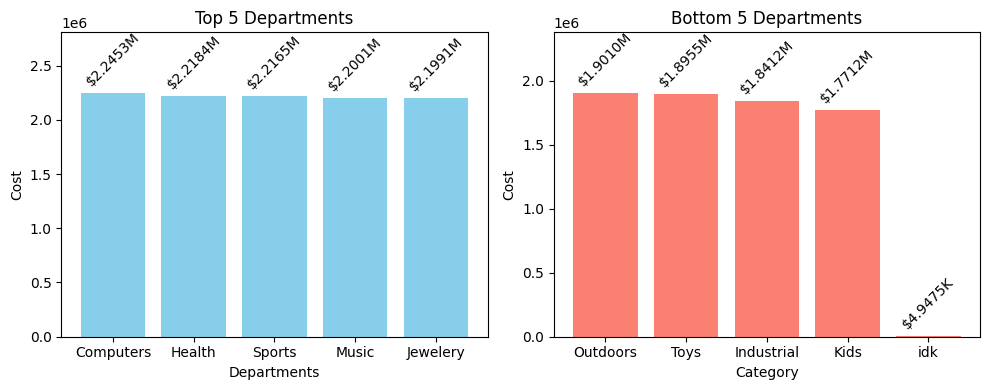

In [9]:
# 1. Sort the Departments by spending
sortedDeps = result.sort_values(by='cost', ascending=False)

# 2. Get the top 5 departments and the bottom 5 departments in terms of spending
top5_df = sortedDeps.head(5)
bottom5_df = sortedDeps.tail(5)
print(top5_df)
print(bottom5_df)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# 3. Plot the first DataFrame on the first axis (ax1)
TopBars = ax1.bar(top5_df['department'], top5_df['cost'], color='skyblue')
ax1.bar_label(TopBars, labels=[currency_fmt(x) for x in top5_df['cost']], padding=3, rotation=45)
ax1.set_title('Top 5 Departments')
ax1.set_xlabel('Departments')
ax1.set_ylabel('Cost')
ax1.set_ylim(0, top5_df['cost'].max() * 1.25) # Added padding for rotated text

# 4. Plot the second DataFrame on the second axis (ax2)
BottomBars = ax2.bar(bottom5_df['department'], bottom5_df['cost'], color='salmon')
ax2.bar_label(BottomBars, labels=[currency_fmt(x) for x in bottom5_df['cost']], padding=3, rotation=45)
ax2.set_title('Bottom 5 Departments')
ax2.set_xlabel('Category')
ax2.set_ylabel('Cost')
ax2.set_ylim(0, bottom5_df['cost'].max() * 1.25)

# 5. Adjust layout for better spacing and display the plot
plt.tight_layout() #
plt.show()

# Student Purchases

484 Student Purchases
Total Costs: 2249310.2300000004
Student Purchases by Department:
     department  total_cost  purchase_count
13     Jewelery   124661.78              30
8        Garden   129836.10              27
14         Kids   128767.65              27
18        Shoes   125712.93              27
1          Baby   110643.89              25
5     Computers   107412.77              24
15       Movies   122562.34              24
11         Home   119214.46              23
16        Music   103167.58              22
2        Beauty    98145.55              22
19       Sports    91790.33              22
7         Games   102122.37              21
0    Automotive    87604.52              21
21         Toys   107266.22              21
17     Outdoors   102124.68              20
12   Industrial   107203.69              20
6   Electronics    93177.39              20
3         Books    65288.63              19
10       Health    88838.73              19
9       Grocery    83158.13      

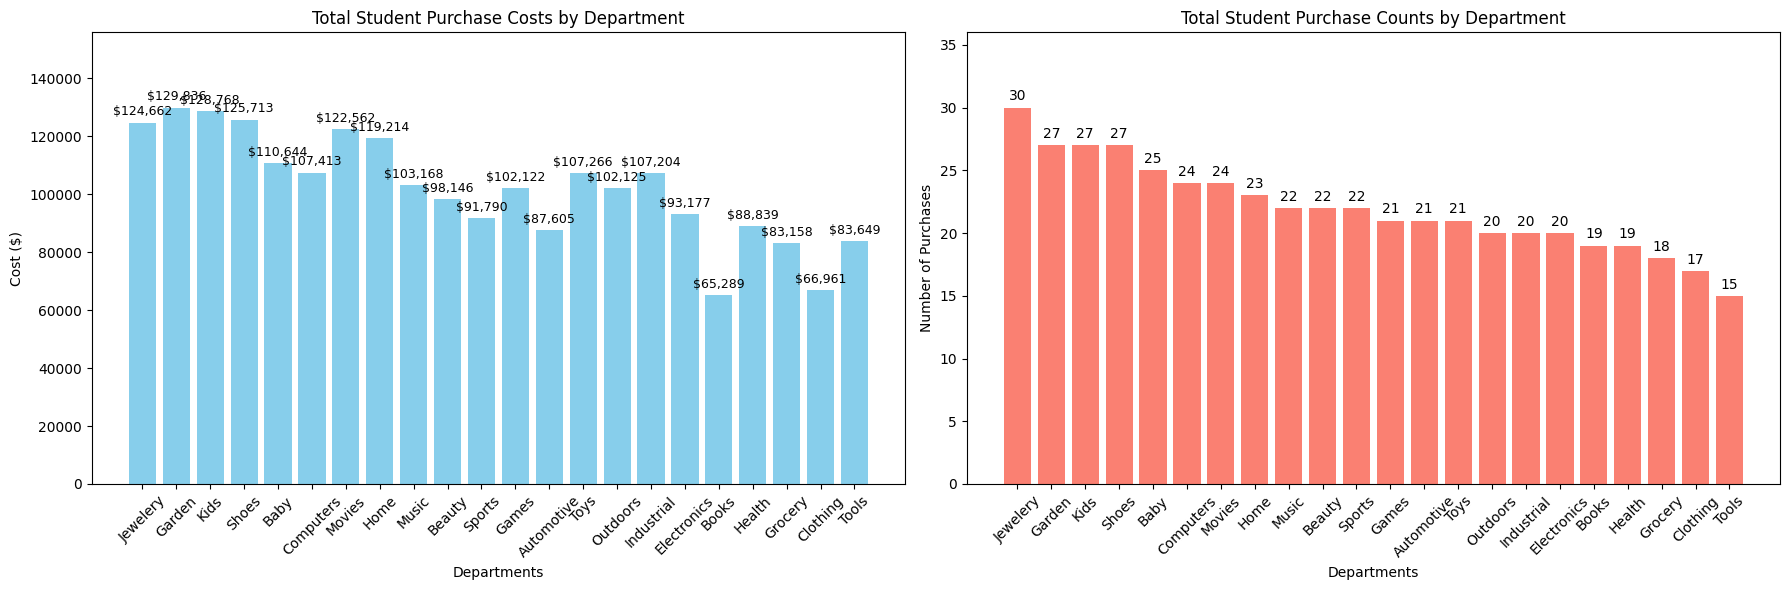

In [10]:
students = df[df['email'].astype(str).str.endswith('.edu')]

StudentNum = len(students)
StudentSum = students['cost'].sum()
print(f"{StudentNum} Student Purchases") 
print(f"Total Costs: {StudentSum}") 

# Group by the 'Department' section
    # sum the 'Cost' sections
    # find the total number of records in each section
studentsSorted = students.groupby('department')['cost'].agg(
    total_cost='sum', 
    purchase_count='count'
).reset_index()

# Sort by purchase count to see the busiest departments
studentsSorted = studentsSorted.sort_values(by='purchase_count', ascending=False)

print("Student Purchases by Department:")
print(studentsSorted)

# Create the figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# --- Plot 1: Total Student Purchase Costs ---
TotalCosts = ax1.bar(studentsSorted['department'], studentsSorted['total_cost'], color='skyblue')
ax1.set_title('Total Student Purchase Costs by Department')
ax1.set_xlabel('Departments')
ax1.set_ylabel('Cost ($)')
ax1.tick_params(axis='x', rotation=45) # Rotate labels for readability
# Set y-limit slightly higher than max value for space
ax1.set_ylim(0, studentsSorted['total_cost'].max() * 1.15) 

# Add currency labels above bars
ax1.bar_label(TotalCosts, fmt='${:,.0f}', padding=3, fontsize=9)
ax1.set_ylim(0, studentsSorted['total_cost'].max() * 1.2) # Extra space for labels

# --- Plot 2: Total Student Purchase Count ---
TotalPurchases = ax2.bar(studentsSorted['department'], studentsSorted['purchase_count'], color='salmon')
ax2.set_title('Total Student Purchase Counts by Department')
ax2.set_xlabel('Departments')
ax2.set_ylabel('Number of Purchases')
ax2.tick_params(axis='x', rotation=45) # Rotate labels for readability
# Set y-limit slightly higher than max value for space
ax2.set_ylim(0, studentsSorted['purchase_count'].max() * 1.15)

# Add count labels above bars
ax2.bar_label(TotalPurchases, padding=3, fontsize=10)
ax2.set_ylim(0, studentsSorted['purchase_count'].max() * 1.2) # Extra space for labels

plt.tight_layout()
plt.show()

# Credit Card Analysis

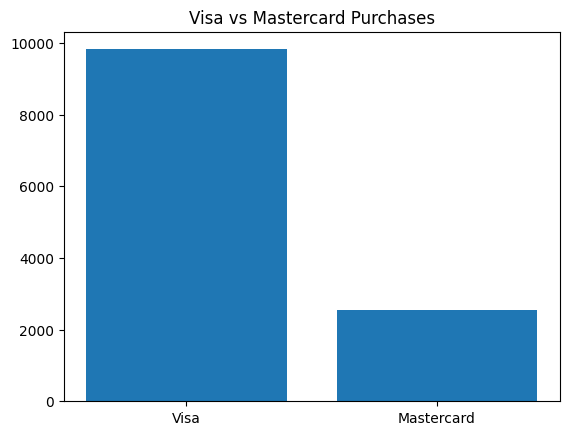

9821
2548


In [11]:
Visa = df['card'].astype(str).str.startswith('4')
Mastercard = df[df['card'].astype(str).str.startswith(('5', '2'))]
VRows = len(Visa)
MRows = len(Mastercard)
cardCats = ['Visa','Mastercard']
cardVals = [VRows,MRows]
plt.bar(cardCats,cardVals)
plt.title('Visa vs Mastercard Purchases')
plt.ylabel('')
plt.show()
print(VRows)
print(MRows)

# Target Survey

['3173414172', '3179048696', '2606929820', '7657219400', '2607705334', '7651240265', '3171617740', '2602196003', '8123095228', '5744064183', '5745279763', '3177219252', '2604655969', '3179458636', '3174936222', '3172808818', '7651440008', '8128699208', '2609962585', '7655686525', '5746452305', '7655925170', '8125007486', '3174794478', '7659520692', '3176362188', '2192565488', '8127613972', '2603206604', '8122018959', '5747590370', '2601959197', '7659894358', '3174793904', '8125484845', '8127621916', '7657150872', '3174580844', '2603846804', '8128236371', '8122909854', '3178819882', '2605886905', '2605130066', '3176090461', '2605554956', '3178180887', '7657771225', '2609605499', '8125507518', '7658963911', '8128446815', '3171199429', '8123328753', '8126114609', '7656836396', '2609695035', '3174780453', '8126813465', '8123589506', '5748605198', '7654598519', '8122006472', '8121624058', '5749990310', '5741264454', '5749287021', '2604873364', '8126945308', '8125212532', '8128601849', '2608

Text(0, 0.5, '')

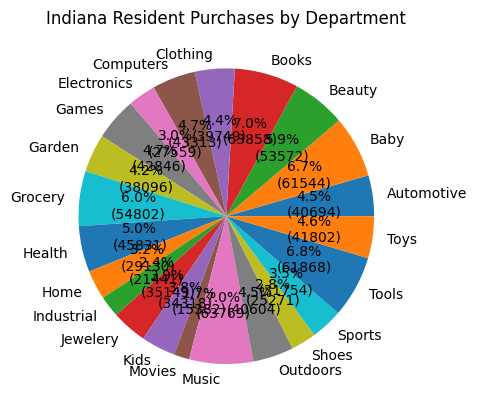

In [12]:
Survey = df[df['state'] == 'Indiana']

pNumberList = Survey['phoneNumber'].tolist()
print(pNumberList)

surveyNum = len(Survey)
surveySum = Survey['cost'].sum()

print(f"{surveyNum} Indiana Resident Purchases") 
print(f"Total Costs: {surveySum}")

SurveySorted = Survey.groupby('department')['cost'].sum().reset_index()

print("Indiana Resident Purchases by Department")
print(SurveySorted)

plt.pie(SurveySorted['cost'], 
        labels=SurveySorted['department'], 
        autopct=lambda pct: apct(pct, SurveySorted['cost'])
)
plt.title('Indiana Resident Purchases by Department')
plt.ylabel('')

# Top Purchasers

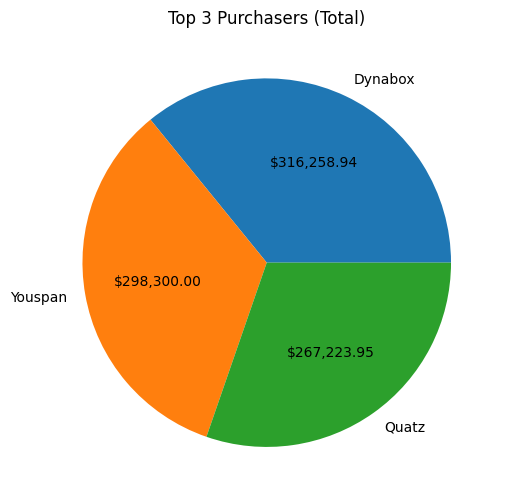

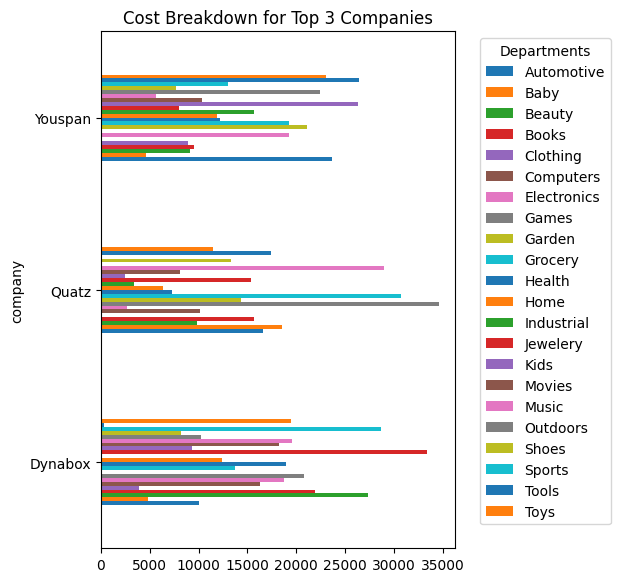

In [13]:
company_totals = df.groupby('company')['cost'].sum().sort_values(ascending=False)

# 2. Get the Names of the Top 3 Companies
top3_names = company_totals.head(3).index
top3_values = company_totals.head(3).values

# --- PIE CHART (Top 3 Total Spenders) ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(top3_values, labels=top3_names, autopct=lambda p: f'${p*sum(top3_values)/100:,.2f}')
plt.title('Top 3 Purchasers (Total)')

plt.tight_layout()
plt.show()

# --- BAR CHART (Breakdown for those same 3) ---
# Filter original df for only these 3 companies
top3_details = df[df['company'].isin(top3_names)]
pivot_df = top3_details.groupby(['company', 'department'])['cost'].sum().unstack()

# Plot on the second subplot
ax2 = plt.subplot(1, 2, 2)
pivot_df.plot(kind='barh', ax=ax2, figsize=(10, 6), stacked=False)
plt.title('Cost Breakdown for Top 3 Companies')
plt.legend(title='Departments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()